# Imports

In [1]:
import numpy as np
from matplotlib.image import imread
import matplotlib.pyplot as plt
!pip install scikit-learn
from sklearn.decomposition import PCA


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Raw image

In [2]:
image_raw = imread("photo.png")
print("Original shape:", image_raw.shape)
print(image_raw)

Original shape: (1114, 1988, 4)
[[[0.6039216  0.73333335 0.8980392  1.        ]
  [0.6039216  0.73333335 0.8980392  1.        ]
  [0.6039216  0.73333335 0.8980392  1.        ]
  ...
  [0.64705884 0.76862746 0.9137255  1.        ]
  [0.64705884 0.76862746 0.9137255  1.        ]
  [0.64705884 0.76862746 0.9137255  1.        ]]

 [[0.6039216  0.7372549  0.9019608  1.        ]
  [0.6039216  0.7372549  0.9019608  1.        ]
  [0.6039216  0.7372549  0.9019608  1.        ]
  ...
  [0.64705884 0.76862746 0.9137255  1.        ]
  [0.64705884 0.76862746 0.9137255  1.        ]
  [0.64705884 0.76862746 0.9137255  1.        ]]

 [[0.6039216  0.7372549  0.9019608  1.        ]
  [0.6039216  0.7372549  0.9019608  1.        ]
  [0.6039216  0.7372549  0.9019608  1.        ]
  ...
  [0.64705884 0.76862746 0.9137255  1.        ]
  [0.64705884 0.76862746 0.9137255  1.        ]
  [0.64705884 0.76862746 0.9137255  1.        ]]

 ...

 [[0.44313726 0.54509807 0.6745098  1.        ]
  [0.45490196 0.54901963 0

# Black and white conversion

In [3]:
image_sum = image_raw.sum(axis=2)
image_bw = image_sum/image_sum.max()
print(image_sum.shape)
print(image_bw.shape)

(1114, 1988)
(1114, 1988)


# PCA

In [4]:
pca = PCA()
pca.fit(image_bw)
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Graph

Number of components explaining 95% variance: 88


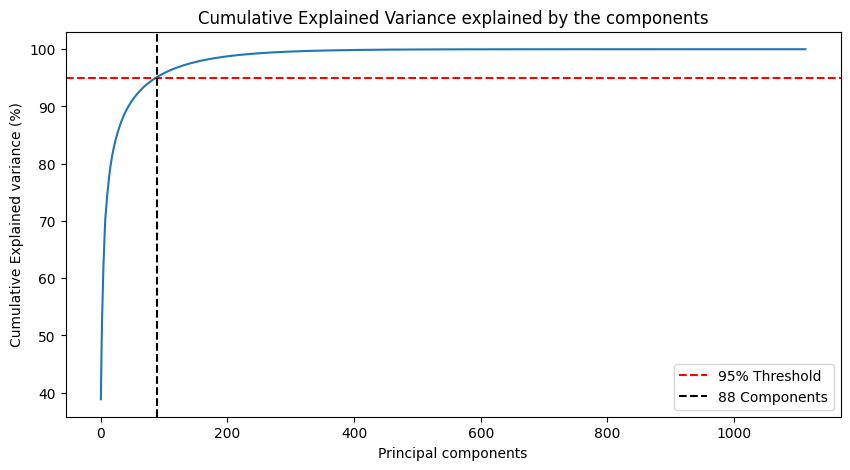

In [5]:
k_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Number of components explaining 95% variance: {k_95}")

plt.figure(figsize=(10, 5))
plt.plot(cumsum * 100)
plt.axhline(y=95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=k_95, color='k', linestyle='--', label=f'{k_95} Components')
plt.title("Cumulative Explained Variance explained by the components")
plt.xlabel("Principal components")
plt.ylabel("Cumulative Explained variance (%)")
plt.legend()
plt.show()

# Image reconstruction

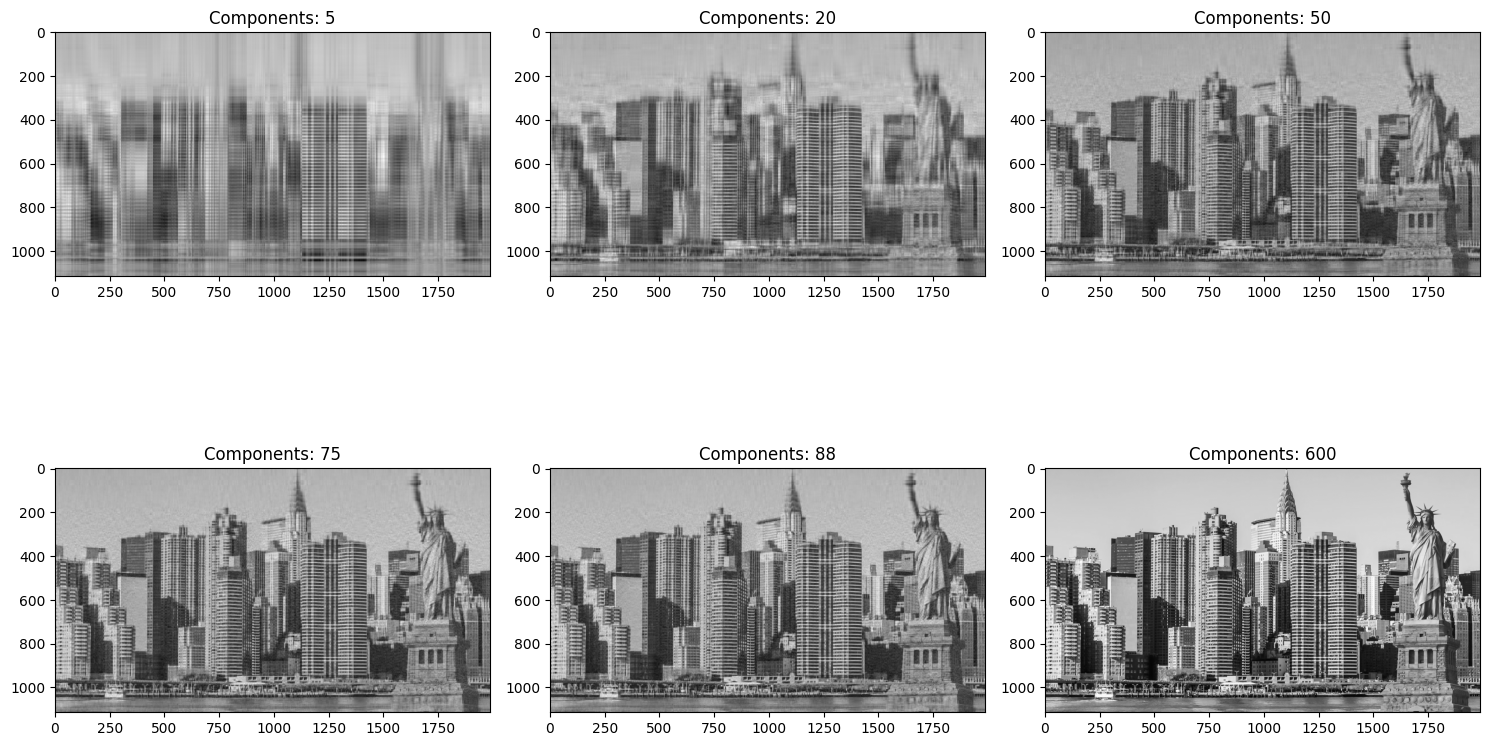

In [8]:
test_comps= [5, 20, 50, 75, 88, 600]
fig, axis = plt.subplots(2, 3, figsize=(15, 10))

for x, y in zip(axis.flat, test_comps):
    pca = PCA(n_components=y)
    image_compressed = pca.fit_transform(image_bw)
    image_reconstructed = pca.inverse_transform(image_compressed)
    x.imshow(image_reconstructed, cmap='gray')
    x.set_title(f"Components: {y}")

plt.tight_layout()
plt.show()